## Ejercicio 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

df = pd.read_csv("../data/raw/guatemala_temperatura.csv", parse_dates=["month"])
df.head()

,month,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
0,1950-01-01,1950,1,16.685643,20.762313,21.077662,21.661654,21.679957,21.835225,22.458468
1,1950-02-01,1950,2,15.781276,21.051057,21.518684,22.132758,22.062957,21.964048,22.216061
2,1950-03-01,1950,3,17.330139,23.197594,23.838886,24.374884,24.100146,23.304599,22.380270
3,1950-04-01,1950,4,16.499826,23.661600,24.452373,25.059722,24.752231,24.059086,22.955561
4,1950-05-01,1950,5,19.011177,24.804521,25.501737,26.154377,25.941164,25.252762,23.687375


In [2]:
df.describe()

,month,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
count,918,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,1988-03-16 18:29:01.176470,1987.751634,6.480392,18.736168,23.050184,23.443820,24.096186,24.066521,24.010561,23.960867
min,1950-01-01 00:00:00,1950.000000,1.000000,14.198656,18.970146,19.145766,19.837591,19.960146,20.486906,21.566859
25%,1969-02-08 00:00:00,1969.000000,3.000000,17.159645,21.815698,22.066246,22.716301,22.799033,22.936150,23.174425
50%,1988-03-16 12:00:00,1988.000000,6.000000,19.078054,23.256937,23.643262,24.315492,24.274114,24.213858,24.070931
75%,2007-04-23 12:00:00,2007.000000,9.000000,20.337119,24.137825,24.574924,25.215864,25.169290,24.967106,24.638497
max,2026-06-01 00:00:00,2026.000000,12.000000,21.959664,28.686405,29.736339,30.293318,29.804204,28.346901,26.876606
std,NaN,22.096630,3.453879,1.826790,1.568933,1.716298,1.710498,1.599642,1.313116,0.965742


In [3]:
capas = [
    "temperature_2m_c",
    "soil_temperature_layer_1_c",
    "soil_temperature_layer_2_c",
    "soil_temperature_layer_3_c",
    "soil_temperature_layer_4_c",
]

for c_ in capas:
    fmax = df.loc[df[c_].idxmax()]
    fmin = df.loc[df[c_].idxmin()]
    print(f"{c_}: max={fmax[c_]:.2f} ({fmax['month'].date()})  min={fmin[c_]:.2f} ({fmin['month'].date()})")

temperature_2m_c: max=28.69 (2024-05-01)  min=18.97 (1956-01-01)
soil_temperature_layer_1_c: max=30.29 (2024-05-01)  min=19.84 (1956-01-01)
soil_temperature_layer_2_c: max=29.80 (2024-05-01)  min=19.96 (1956-01-01)
soil_temperature_layer_3_c: max=28.35 (2024-05-01)  min=20.49 (1956-01-01)
soil_temperature_layer_4_c: max=26.88 (2024-06-01)  min=21.57 (1976-02-01)


In [4]:
df["t"] = (df["year"] - df["year"].min()) + (df["month_num"] - 1) / 12

for c_ in capas:
    slope, intercept, r, p, se = stats.linregress(df["t"], df[c_])
    print(f"{c_}: {slope:.4f} C/año  (p={p:.4g})")

temperature_2m_c: 0.0171 C/año  (p=1.491e-13)
soil_temperature_layer_1_c: 0.0168 C/año  (p=2.936e-11)
soil_temperature_layer_2_c: 0.0167 C/año  (p=1.301e-12)
soil_temperature_layer_3_c: 0.0166 C/año  (p=6.061e-18)
soil_temperature_layer_4_c: 0.0165 C/año  (p=1.866e-32)


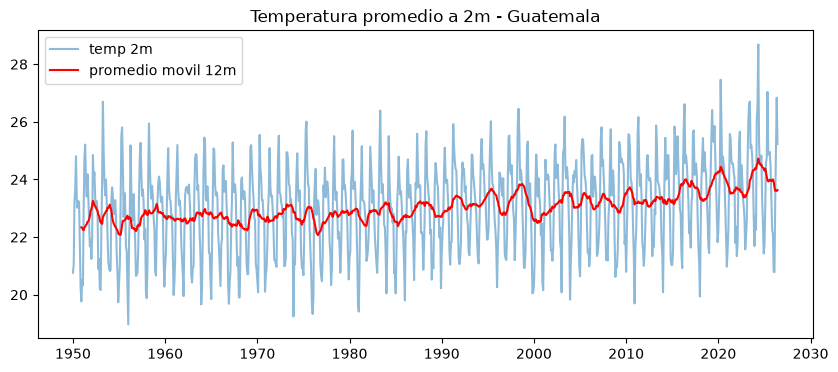

In [5]:
df["temp_2m_rolling"] = df["temperature_2m_c"].rolling(12).mean()
plt.figure(figsize=(10, 4))
plt.plot(df["month"], df["temperature_2m_c"], alpha=0.5, label="temp 2m")
plt.plot(df["month"], df["temp_2m_rolling"], color="red", label="promedio movil 12m")
plt.legend()
plt.title("Temperatura promedio a 2m - Guatemala")
plt.show()

## Ejercicio 2

In [6]:
df = df.sort_values("month").reset_index(drop=True)
train = df.iloc[:-36]
test = df.iloc[-36:]

print("train:", train.shape, train["month"].min().date(), "-", train["month"].max().date())
print("test: ", test.shape, test["month"].min().date(), "-", test["month"].max().date())

train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

train: (882, 12) 1950-01-01 - 2023-06-01
test:  (36, 12) 2023-07-01 - 2026-06-01
